In [2]:
from pathlib import Path

base = Path("/Users/angga0704/VSCode/Lomba/IDSC/Results")
for folder in sorted(base.iterdir()):
    if folder.is_dir():
        print(f"\n=== {folder.name} ===")
        for p in sorted(folder.rglob("*")):
            if p.is_file():
                print(p.relative_to(base))


=== Classical_Final ===
Classical_Final/best_model_summary_round2.json
Classical_Final/config.json
Classical_Final/final_summary_round2.csv
Classical_Final/metrics/cv_results_logistic.csv
Classical_Final/metrics/cv_results_random_forest.csv
Classical_Final/metrics/cv_results_ros_logistic.csv
Classical_Final/metrics/cv_results_xgboost.csv
Classical_Final/metrics/details_logistic.json
Classical_Final/metrics/details_random_forest.json
Classical_Final/metrics/details_ros_logistic.json
Classical_Final/metrics/details_xgboost.json
Classical_Final/metrics/threshold_table_logistic.csv
Classical_Final/metrics/threshold_table_random_forest.csv
Classical_Final/metrics/threshold_table_ros_logistic.csv
Classical_Final/metrics/threshold_table_xgboost.csv
Classical_Final/predictions/holdout_predictions_logistic.csv
Classical_Final/predictions/holdout_predictions_random_forest.csv
Classical_Final/predictions/holdout_predictions_ros_logistic.csv
Classical_Final/predictions/holdout_predictions_xgboost

Setup Path & Import

In [3]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = Path(".").resolve().parent if Path(".").resolve().name == "Notebooks" else Path(".").resolve()
RESULTS = BASE / "Results"
REPORTS = BASE / "Reports"

REPORTS.mkdir(parents=True, exist_ok=True)
(REPORTS / "tables").mkdir(parents=True, exist_ok=True)
(REPORTS / "figures").mkdir(parents=True, exist_ok=True)

CLASSICAL_DIR = RESULTS / "Classical_Final"
CNN_V1V3_DIR = RESULTS / "cnn_v1v3_final"
CNN_12_DIR = RESULTS / "cnn_12lead_ablation"
INTERP_DIR = RESULTS / "interpretability"

print("BASE:", BASE)
print("RESULTS:", RESULTS)
print("REPORTS:", REPORTS)

BASE: /Users/angga0704/VSCode/Lomba/IDSC
RESULTS: /Users/angga0704/VSCode/Lomba/IDSC/Results
REPORTS: /Users/angga0704/VSCode/Lomba/IDSC/Reports


Helper Functions

In [4]:
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def fmt_pm(mean, std, digits=3):
    return f"{mean:.{digits}f} ± {std:.{digits}f}"

Load Classical ML Result

In [5]:
classical_df = pd.read_csv(CLASSICAL_DIR / "final_summary_round2.csv")
classical_df

,model,cv_best_f1,oof_threshold,oof_f1,oof_balanced_accuracy,oof_precision,oof_recall,oof_roc_auc,oof_pr_auc,holdout_f1,holdout_balanced_accuracy,holdout_precision,holdout_recall,holdout_roc_auc,holdout_pr_auc,best_params
0,random_forest,0.577143,0.45,0.612613,0.761056,0.607143,0.618182,0.839619,0.583947,0.400000,0.625616,0.666667,0.285714,0.752463,0.517519,"{""select__k"": 45, ""clf__n_estimators"": 200, ""c..."
1,xgboost,0.635084,0.47,0.644628,0.795593,0.590909,0.709091,0.848670,0.558750,0.380952,0.616995,0.571429,0.285714,0.730296,0.516722,"{""select__k"": 90, ""clf__subsample"": 1.0, ""clf_..."
2,logistic,0.520400,0.48,0.540146,0.738110,0.451220,0.672727,0.775387,0.434601,0.235294,0.562808,0.666667,0.142857,0.731527,0.509991,"{""select__k"": 30, ""clf__solver"": ""lbfgs"", ""clf..."
3,ros_logistic,0.528923,0.55,0.549618,0.739936,0.473684,0.654545,0.780627,0.445443,0.125000,0.527094,0.500000,0.071429,0.742611,0.472851,"{""select__k"": 30, ""ros__sampling_strategy"": 0...."


Pilih classical model yang akan digunakan

In [6]:
# ambil model-model yang paling relevan buat comparison final
classical_keep = classical_df[classical_df["model"].isin(["xgboost", "random_forest"])].copy()

classical_keep = classical_keep[[
    "model",
    "oof_threshold",
    "holdout_f1",
    "holdout_recall",
    "holdout_balanced_accuracy",
    "holdout_roc_auc",
    "holdout_pr_auc",
    "best_params"
]].copy()

classical_keep["lead_setting"] = "V1-V3"
classical_keep["category"] = "Classical ML"
classical_keep

,model,oof_threshold,holdout_f1,holdout_recall,holdout_balanced_accuracy,holdout_roc_auc,holdout_pr_auc,best_params,lead_setting,category
0,random_forest,0.45,0.400000,0.285714,0.625616,0.752463,0.517519,"{""select__k"": 45, ""clf__n_estimators"": 200, ""c...",V1-V3,Classical ML
1,xgboost,0.47,0.380952,0.285714,0.616995,0.730296,0.516722,"{""select__k"": 90, ""clf__subsample"": 1.0, ""clf_...",V1-V3,Classical ML


Load CNN Summaries

In [7]:
cnn_v1v3_summary = pd.read_csv(CNN_V1V3_DIR / "multi_seed_summary.csv")
cnn_v1v3_agg = load_json(CNN_V1V3_DIR / "multi_seed_aggregate.json")

cnn_12_summary = pd.read_csv(CNN_12_DIR / "multi_seed_summary.csv")
cnn_12_agg = load_json(CNN_12_DIR / "multi_seed_aggregate.json")

cnn_v1v3_summary, cnn_v1v3_agg, cnn_12_summary, cnn_12_agg

(   seed  best_epoch  best_threshold  train_auc   val_auc  test_auc  train_f1  \
 0   123          24            0.48   0.995902  0.920949  0.853448  0.933333   
 1  2026           6            0.42   0.891952  0.845850  0.857143  0.705882   
 2    42          17            0.51   0.986836  0.964427  0.862069  0.875000   
 
      val_f1   test_f1  train_recall  val_recall  test_recall  \
 0  0.857143  0.666667      0.954545    0.818182     0.500000   
 1  0.608696  0.645161      0.681818    0.636364     0.714286   
 2  0.869565  0.640000      0.954545    0.909091     0.571429   
 
    test_balanced_accuracy  test_precision  test_pr_auc overfitting_risk_level  \
 0                0.750000        1.000000     0.793635                   mild   
 1                0.796798        0.588235     0.733426                    low   
 2                0.759852        0.727273     0.716459               moderate   
 
                                    overfitting_flags  
 0     val_test_f1_gap_hig

Pilih best seed CNN

In [8]:
best_seed_v1v3 = cnn_v1v3_summary.sort_values(
    by=["test_f1", "test_recall", "test_auc"],
    ascending=False
).iloc[0]

best_seed_v1v3

seed                                                                 123
best_epoch                                                            24
best_threshold                                                      0.48
train_auc                                                       0.995902
val_auc                                                         0.920949
test_auc                                                        0.853448
train_f1                                                        0.933333
val_f1                                                          0.857143
test_f1                                                         0.666667
train_recall                                                    0.954545
val_recall                                                      0.818182
test_recall                                                          0.5
test_balanced_accuracy                                              0.75
test_precision                                     

Comparison Table

In [9]:
rows = []

# Classical models
for _, row in classical_keep.iterrows():
    rows.append({
        "Model": row["model"].replace("_", " ").title(),
        "Category": row["category"],
        "Leads": row["lead_setting"],
        "F1": row["holdout_f1"],
        "Recall": row["holdout_recall"],
        "Balanced Accuracy": row["holdout_balanced_accuracy"],
        "ROC-AUC": row["holdout_roc_auc"],
        "PR-AUC": row["holdout_pr_auc"],
        "Stability / Note": "Single split classical benchmark"
    })

# CNN V1-V3 best seed
rows.append({
    "Model": f"CNN V1-V3 (best seed={int(best_seed_v1v3['seed'])})",
    "Category": "Deep Learning",
    "Leads": "V1-V3",
    "F1": best_seed_v1v3["test_f1"],
    "Recall": best_seed_v1v3["test_recall"],
    "Balanced Accuracy": best_seed_v1v3["test_balanced_accuracy"],
    "ROC-AUC": best_seed_v1v3["test_auc"],
    "PR-AUC": best_seed_v1v3["test_pr_auc"],
    "Stability / Note": f"Overfitting risk: {best_seed_v1v3['overfitting_risk_level']}"
})

# CNN V1-V3 multi-seed mean
rows.append({
    "Model": "CNN V1-V3 (multi-seed mean)",
    "Category": "Deep Learning",
    "Leads": "V1-V3",
    "F1": cnn_v1v3_agg["mean_test_f1"],
    "Recall": cnn_v1v3_agg["mean_test_recall"],
    "Balanced Accuracy": cnn_v1v3_agg["mean_test_balanced_accuracy"],
    "ROC-AUC": cnn_v1v3_agg["mean_test_auc"],
    "PR-AUC": np.nan,
    "Stability / Note": (
        f"F1 std={cnn_v1v3_agg['std_test_f1']:.3f}, "
        f"Recall std={cnn_v1v3_agg['std_test_recall']:.3f}, "
        f"AUC std={cnn_v1v3_agg['std_test_auc']:.3f}"
    )
})

# CNN 12-lead multi-seed mean
rows.append({
    "Model": "CNN 12-lead (multi-seed mean)",
    "Category": "Deep Learning",
    "Leads": "All 12 Leads",
    "F1": cnn_12_agg["mean_test_f1"],
    "Recall": cnn_12_agg["mean_test_recall"],
    "Balanced Accuracy": cnn_12_agg["mean_test_balanced_accuracy"],
    "ROC-AUC": cnn_12_agg["mean_test_auc"],
    "PR-AUC": np.nan,
    "Stability / Note": (
        f"F1 std={cnn_12_agg['std_test_f1']:.3f}, "
        f"Recall std={cnn_12_agg['std_test_recall']:.3f}, "
        f"AUC std={cnn_12_agg['std_test_auc']:.3f}"
    )
})

final_table = pd.DataFrame(rows)
final_table

,Model,Category,Leads,F1,Recall,Balanced Accuracy,ROC-AUC,PR-AUC,Stability / Note
0,Random Forest,Classical ML,V1-V3,0.400000,0.285714,0.625616,0.752463,0.517519,Single split classical benchmark
1,Xgboost,Classical ML,V1-V3,0.380952,0.285714,0.616995,0.730296,0.516722,Single split classical benchmark
2,CNN V1-V3 (best seed=123),Deep Learning,V1-V3,0.666667,0.500000,0.750000,0.853448,0.793635,Overfitting risk: mild
3,CNN V1-V3 (multi-seed mean),Deep Learning,V1-V3,0.650609,0.595238,0.768883,0.857553,NaN,"F1 std=0.012, Recall std=0.089, AUC std=0.004"
4,CNN 12-lead (multi-seed mean),Deep Learning,All 12 Leads,0.325581,1.000000,0.500000,0.659688,NaN,"F1 std=0.000, Recall std=0.000, AUC std=0.019"


Export CSV

In [10]:
final_table_rounded = final_table.copy()

metric_cols = ["F1", "Recall", "Balanced Accuracy", "ROC-AUC", "PR-AUC"]
for c in metric_cols:
    final_table_rounded[c] = final_table_rounded[c].round(3)

final_table_rounded.to_csv(REPORTS / "tables" / "final_model_comparison.csv", index=False)
final_table_rounded

,Model,Category,Leads,F1,Recall,Balanced Accuracy,ROC-AUC,PR-AUC,Stability / Note
0,Random Forest,Classical ML,V1-V3,0.400,0.286,0.626,0.752,0.518,Single split classical benchmark
1,Xgboost,Classical ML,V1-V3,0.381,0.286,0.617,0.730,0.517,Single split classical benchmark
2,CNN V1-V3 (best seed=123),Deep Learning,V1-V3,0.667,0.500,0.750,0.853,0.794,Overfitting risk: mild
3,CNN V1-V3 (multi-seed mean),Deep Learning,V1-V3,0.651,0.595,0.769,0.858,NaN,"F1 std=0.012, Recall std=0.089, AUC std=0.004"
4,CNN 12-lead (multi-seed mean),Deep Learning,All 12 Leads,0.326,1.000,0.500,0.660,NaN,"F1 std=0.000, Recall std=0.000, AUC std=0.019"


Multi Seed Summary untuk CNN V1-V3

In [11]:
cnn_v1v3_seed_table = cnn_v1v3_summary[[
    "seed", "best_epoch", "best_threshold",
    "test_f1", "test_recall", "test_balanced_accuracy", "test_auc",
    "test_precision", "test_pr_auc", "overfitting_risk_level"
]].copy()

cnn_v1v3_seed_table = cnn_v1v3_seed_table.round(3)
cnn_v1v3_seed_table.to_csv(REPORTS / "tables" / "cnn_v1v3_multiseed_summary.csv", index=False)

cnn_v1v3_seed_table

,seed,best_epoch,best_threshold,test_f1,test_recall,test_balanced_accuracy,test_auc,test_precision,test_pr_auc,overfitting_risk_level
0,123,24,0.48,0.667,0.500,0.750,0.853,1.000,0.794,mild
1,2026,6,0.42,0.645,0.714,0.797,0.857,0.588,0.733,low
2,42,17,0.51,0.640,0.571,0.760,0.862,0.727,0.716,moderate


Model Comparison Bar Chart

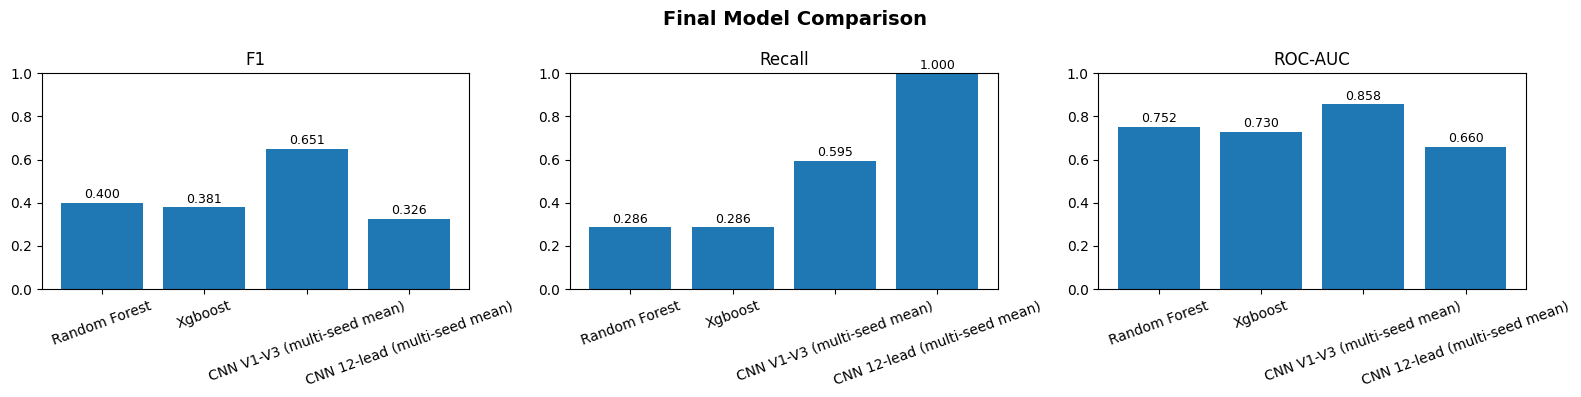

In [12]:
plot_df = final_table.copy()

# pakai model yang paling penting buat figure utama
plot_df = plot_df[plot_df["Model"].isin([
    "Xgboost",
    "Random Forest",
    "CNN V1-V3 (multi-seed mean)",
    "CNN 12-lead (multi-seed mean)"
])].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

metrics_to_plot = ["F1", "Recall", "ROC-AUC"]

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(plot_df["Model"], plot_df[metric])
    ax.set_title(metric)
    ax.set_ylim(0, 1.0)
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(plot_df[metric]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

fig.suptitle("Final Model Comparison", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(REPORTS / "figures" / "final_model_comparison.png", dpi=200, bbox_inches="tight")
plt.show()

Multi Seed Error Bar

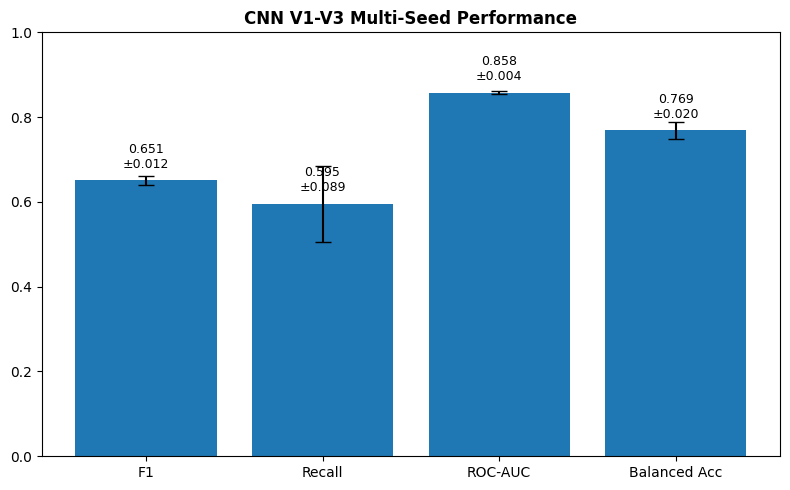

In [13]:
metrics = ["test_f1", "test_recall", "test_auc", "test_balanced_accuracy"]
means = [
    cnn_v1v3_agg["mean_test_f1"],
    cnn_v1v3_agg["mean_test_recall"],
    cnn_v1v3_agg["mean_test_auc"],
    cnn_v1v3_agg["mean_test_balanced_accuracy"],
]
stds = [
    cnn_v1v3_agg["std_test_f1"],
    cnn_v1v3_agg["std_test_recall"],
    cnn_v1v3_agg["std_test_auc"],
    cnn_v1v3_agg["std_test_balanced_accuracy"],
]

labels = ["F1", "Recall", "ROC-AUC", "Balanced Acc"]

plt.figure(figsize=(8, 5))
plt.bar(labels, means, yerr=stds, capsize=6)
plt.ylim(0, 1.0)
plt.title("CNN V1-V3 Multi-Seed Performance", fontweight="bold")
for i, (m, s) in enumerate(zip(means, stds)):
    plt.text(i, m + 0.03, f"{m:.3f}\n±{s:.3f}", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS / "figures" / "cnn_v1v3_multiseed_summary.png", dpi=200, bbox_inches="tight")
plt.show()

Lead Importance

In [14]:
lead_imp = pd.read_csv(INTERP_DIR / "tables" / "permutation_lead_importance_all_12_leads.csv")
lead_imp

,lead,importance
0,V1,0.092426
1,V4,0.069335
2,V6,0.046429
3,III,0.043350
4,aVF,0.042241
5,V2,0.040702
6,aVR,0.025862
7,II,0.018596
8,I,0.016502
9,V5,0.000431


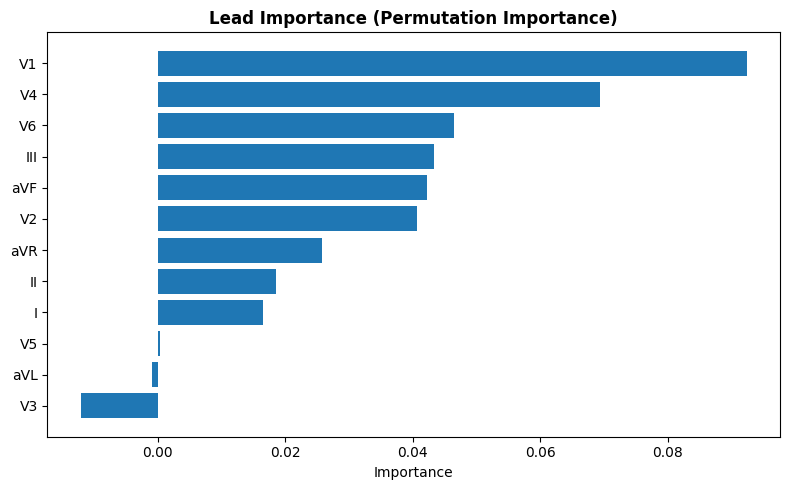

In [15]:
plt.figure(figsize=(8, 5))
plt.barh(lead_imp["lead"][::-1], lead_imp["importance"][::-1])
plt.title("Lead Importance (Permutation Importance)", fontweight="bold")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig(REPORTS / "figures" / "lead_importance_permutation.png", dpi=200, bbox_inches="tight")
plt.show()

Top Feature Importance

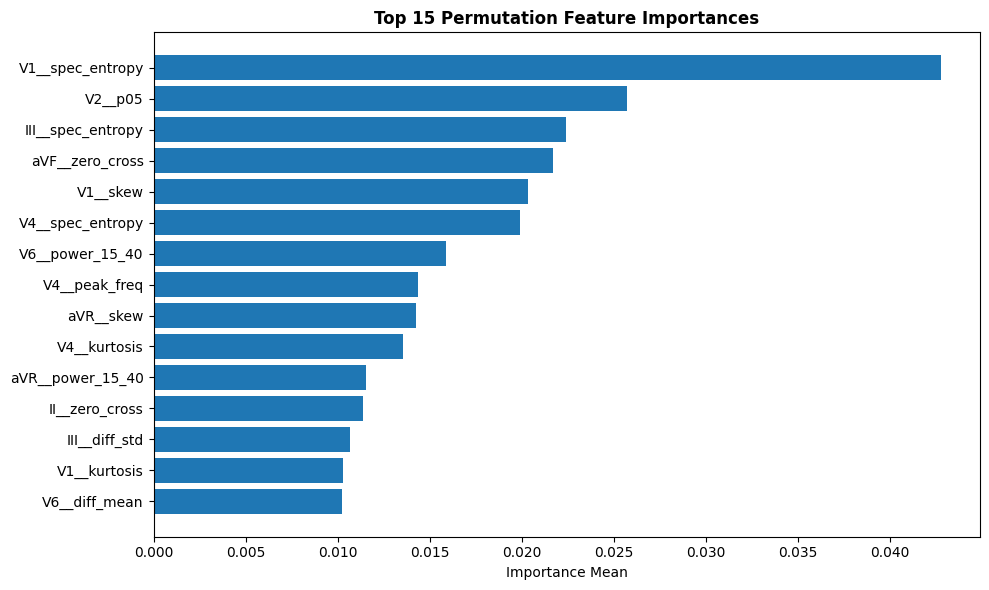

In [16]:
top_feat = pd.read_csv(INTERP_DIR / "tables" / "permutation_feature_importance_all_12_leads.csv").head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_feat["feature"][::-1], top_feat["importance_mean"][::-1])
plt.title("Top 15 Permutation Feature Importances", fontweight="bold")
plt.xlabel("Importance Mean")
plt.tight_layout()
plt.savefig(REPORTS / "figures" / "top_feature_importance_permutation.png", dpi=200, bbox_inches="tight")
plt.show()

Textual Summary

In [ ]:
summary_lines = [
    "Final Summary",
    "=============",
    f"Best classical benchmark: XGBoost / RandomForest on V1-V3.",
    f"Best deep model: CNN V1-V3.",
    f"CNN V1-V3 multi-seed mean F1 = {cnn_v1v3_agg['mean_test_f1']:.3f} ± {cnn_v1v3_agg['std_test_f1']:.3f}",
    f"CNN V1-V3 multi-seed mean Recall = {cnn_v1v3_agg['mean_test_recall']:.3f} ± {cnn_v1v3_agg['std_test_recall']:.3f}",
    f"CNN V1-V3 multi-seed mean ROC-AUC = {cnn_v1v3_agg['mean_test_auc']:.3f} ± {cnn_v1v3_agg['std_test_auc']:.3f}",
    f"CNN 12-lead mean F1 = {cnn_12_agg['mean_test_f1']:.3f}, indicating degraded performance compared to V1-V3.",
    "Feature importance analysis identified V1 as the most informative lead, followed by V2-related contributions.",
]

summary_text = "\n".join(summary_lines)
print(summary_text)

with open(REPORTS / "tables" / "final_summary_notes.txt", "w", encoding="utf-8") as f:
    f.write(summary_text)

Final Summary
Best classical benchmark: XGBoost / RandomForest on V1-V3.
Best deep model: CNN V1-V3.
CNN V1-V3 multi-seed mean F1 = 0.651 ± 0.012
CNN V1-V3 multi-seed mean Recall = 0.595 ± 0.089
CNN V1-V3 multi-seed mean ROC-AUC = 0.858 ± 0.004
CNN 12-lead mean F1 = 0.326, indicating degraded performance compared to V1-V3.
Feature importance analysis identified V1 as the most informative lead, followed by V2-related contributions.
